# VGG16 Image Classifier — Alzheimer's MRI Classification

Transfer learning with pre-trained VGG16 on the Alzheimer's MRI dataset (4 classes).  
Includes data augmentation, proper normalization, phase-1 head training, phase-2 fine-tuning of the last conv block, EarlyStopping, training curves, and a reusable prediction function.

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import load_img, img_to_array

# Image dimensions
IMG_WIDTH, IMG_HEIGHT = 150, 150

# Training parameters
BATCH_SIZE = 32
EPOCHS_PHASE1 = 15   # Head-only training
EPOCHS_PHASE2 = 10   # Fine-tuning last conv block

In [8]:
# # Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil

# Clean previous extraction
shutil.rmtree('/content/data', ignore_errors=True)
shutil.rmtree('/content/AugmentedAlzheimerDataset', ignore_errors=True)

# Unzip from Drive
os.system("unzip -oq /content/drive/MyDrive/dataset.zip -d /content/")

# Auto-detect dataset path
DATASET_PATH = None
for root, dirs, files in os.walk("/content"):
    if "NonDemented" in dirs:
        DATASET_PATH = root
        break

if DATASET_PATH:
    print("Dataset found at:", DATASET_PATH)
    print("Classes:", os.listdir(DATASET_PATH))
else:
    print("Dataset not found. Contents of /content:")
    print(os.listdir("/content"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found at: /content/data/AugmentedAlzheimerDataset
Classes: ['ModerateDemented', 'MildDemented', 'VeryMildDemented', 'NonDemented']


In [10]:
class_names = sorted(os.listdir(DATASET_PATH))
print(class_names)

['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


## Data Loading & Preprocessing

Loads Alzheimer's MRI Dataset from local Colab storage using `image_dataset_from_directory`.

**Folder structure:**
```
AugmentedAlzheimerDataset/
├── NonDemented/
├── VeryMildDemented/
├── MildDemented/
└── ModerateDemented/
```

**Split:** 70% Train / 15% Validation / 15% Test  
**Classes:** NonDemented, VeryMildDemented, MildDemented, ModerateDemented (4 classes)

In [11]:
# Dataset path for Windows (Antigravity environment)
DATA_DIR = "/content/data/AugmentedAlzheimerDataset"

print("Loading Alzheimer's MRI dataset...")
print(f"Data directory: {DATA_DIR}")
print(os.listdir(DATA_DIR))

try:
    # ── Load training split (70%) ──
    train_dataset = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        image_size=(IMG_WIDTH, IMG_HEIGHT),
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        validation_split=0.30,   # hold out 30% for val + test
        subset='training',
        seed=42
    )

    # ── Load holdout split (30%) — will be split 50/50 into val and test ──
    holdout_dataset = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        image_size=(IMG_WIDTH, IMG_HEIGHT),
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        validation_split=0.30,
        subset='validation',
        seed=42
    )

    # ── Split holdout 50/50 into val (15%) and test (15%) ──
    holdout_batches = len(holdout_dataset)
    val_batches     = holdout_batches // 2

    val_dataset  = holdout_dataset.take(val_batches)
    test_dataset = holdout_dataset.skip(val_batches)

    # Class names detected from folder names
    class_names = train_dataset.class_names
    num_classes = len(class_names)
    print(f"Classes found     : {class_names}")

    # ── Prefetch datasets (Normalization and Augmentation moved to model logic) ──
    train_ds = train_dataset.prefetch(tf.data.AUTOTUNE)
    val_ds = val_dataset.prefetch(tf.data.AUTOTUNE)
    test_ds = test_dataset.prefetch(tf.data.AUTOTUNE)

    train_samples = len(train_dataset) * BATCH_SIZE
    val_samples   = len(val_dataset)   * BATCH_SIZE
    test_samples  = len(test_dataset)  * BATCH_SIZE

    print(f"Training batches  : {len(train_dataset)}  (~{train_samples} images)")
    print(f"Validation batches: {len(val_dataset)}  (~{val_samples} images)")
    print(f"Test batches      : {len(test_dataset)}  (~{test_samples} images)")
    print("Dataset loaded successfully!")

except Exception as e:
    print(f"Error loading dataset: {e}")
    print("\nMake sure the dataset was copied correctly and contains NonDemented/, VeryMildDemented/, MildDemented/, and ModerateDemented/ subfolders.")

Loading Alzheimer's MRI dataset...
Data directory: /content/data/AugmentedAlzheimerDataset
['ModerateDemented', 'MildDemented', 'VeryMildDemented', 'NonDemented']
Found 33984 files belonging to 4 classes.
Using 23789 files for training.
Found 33984 files belonging to 4 classes.
Using 10195 files for validation.
Classes found     : ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
Training batches  : 744  (~23808 images)
Validation batches: 159  (~5088 images)
Test batches      : 160  (~5120 images)
Dataset loaded successfully!


## Model — VGG16 Transfer Learning

Load VGG16 with ImageNet weights, freeze all base layers, attach a custom classification head using `GlobalAveragePooling2D` (fewer params, better generalization than `Flatten`).

Training is split into two phases:
- **Phase 1**: Train only the custom head (base fully frozen)
- **Phase 2**: Unfreeze the last conv block (`block5`) and fine-tune at a lower learning rate

In [12]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# Build Model with Augmentation
base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.vgg16.preprocess_input(x)
x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(4, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# Compile (with label smoothing)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Class Weights (handle imbalance)
class_weight = {
    0: 1.0,
    1: 1.5,
    2: 1.5,
    3: 2.0
}

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 150, 150,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 150, 150)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 150, 150)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 150, 150)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 150, 150,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 150, 150,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 4, 4, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │      1,028 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Phase 1 — Train Custom Head

EarlyStopping monitors `val_loss` and stops if it doesn't improve for 3 epochs, restoring the best weights automatically.

In [13]:
# Train Phase 1
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=[early_stop]
)

Epoch 1/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 72s 86ms/step - accuracy: 0.3447 - loss: 4.3806 - val_accuracy: 0.4803 - val_loss: 1.2321
Epoch 2/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 69s 93ms/step - accuracy: 0.4329 - loss: 1.8918 - val_accuracy: 0.5263 - val_loss: 1.1354
Epoch 3/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 69s 92ms/step - accuracy: 0.4809 - loss: 1.7491 - val_accuracy: 0.5594 - val_loss: 1.0708
Epoch 4/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 69s 93ms/step - accuracy: 0.5127 - loss: 1.6667 - val_accuracy: 0.5947 - val_loss: 1.0285
Epoch 5/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 68s 92ms/step - accuracy: 0.5323 - loss: 1.6300 - val_accuracy: 0.6061 - val_loss: 1.0017
Epoch 6/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 69s 93ms/step - accuracy: 0.5475 - loss: 1.5837 - val_accuracy: 0.6193 - val_loss: 0.9817
Epoch 7/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 69s 92ms/step - accuracy: 0.5673 - loss: 1.5498 - val_accuracy: 0.6222 - val_loss: 0.9695
Epoch 8/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 69s 93ms/step - accuracy: 0.5746 - loss: 1.5311 - 

## Phase 2 — Fine-Tune Last Conv Block (block5)

Unfreeze VGG16's last convolutional block (`block5_conv1`, `block5_conv2`, `block5_conv3`) and train at a much lower learning rate (`1e-5`).  
This lets the model adapt the high-level ImageNet features to MRI-specific patterns without destroying the earlier layers.

> **Expected gain:** +2–5% val accuracy over phase 1 alone.

In [14]:
# Fine-Tuning (Unfreeze last layers)
base_model.trainable = True

for layer in base_model.layers[:-8]:
    layer.trainable = False

# Recompile with lower LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Train Phase 2
history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight,
    callbacks=[early_stop]
)

# Save final model
model.save('vgg16_alzheimers_classifier.keras')
print("\nModel saved as 'vgg16_alzheimers_classifier.keras'")

Epoch 1/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 120s 155ms/step - accuracy: 0.6654 - loss: 1.3598 - val_accuracy: 0.7592 - val_loss: 0.7957
Epoch 2/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 114s 153ms/step - accuracy: 0.7348 - loss: 1.2209 - val_accuracy: 0.7777 - val_loss: 0.7495
Epoch 3/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 114s 154ms/step - accuracy: 0.7974 - loss: 1.1031 - val_accuracy: 0.8491 - val_loss: 0.6546
Epoch 4/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 114s 153ms/step - accuracy: 0.8417 - loss: 1.0115 - val_accuracy: 0.8933 - val_loss: 0.5806
Epoch 5/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 142s 154ms/step - accuracy: 0.8811 - loss: 0.9267 - val_accuracy: 0.9204 - val_loss: 0.5505
Epoch 6/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 114s 153ms/step - accuracy: 0.9108 - loss: 0.8599 - val_accuracy: 0.9306 - val_loss: 0.5217
Epoch 7/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 114s 153ms/step - accuracy: 0.9321 - loss: 0.8080 - val_accuracy: 0.9397 - val_loss: 0.5006
Epoch 8/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 114s 154ms/step - accuracy: 0.9477 -

## Final Evaluation on Test Set

Evaluate the trained model on the **held-out test set** (15% of data, never seen during training or validation).  
This gives an unbiased measure of how well the model generalizes to new MRI images.

In [15]:
if 'test_ds' in locals():
    print("Evaluating on test set (unseen data)...\n")
    test_loss, test_acc = model.evaluate(test_ds, verbose=1)
    print(f"\n=== Final Test Results ===")
    print(f"Test Accuracy : {test_acc * 100:.2f}%")
    print(f"Test Loss     : {test_loss:.4f}")
else:
    print("Test dataset not found. Run the data loading cell first.")

Evaluating on test set (unseen data)...

160/160 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - accuracy: 0.9738 - loss: 0.4400

=== Final Test Results ===
Test Accuracy : 97.38%
Test Loss     : 0.4400


## Training Curves

Accuracy and loss curves for both training phases.

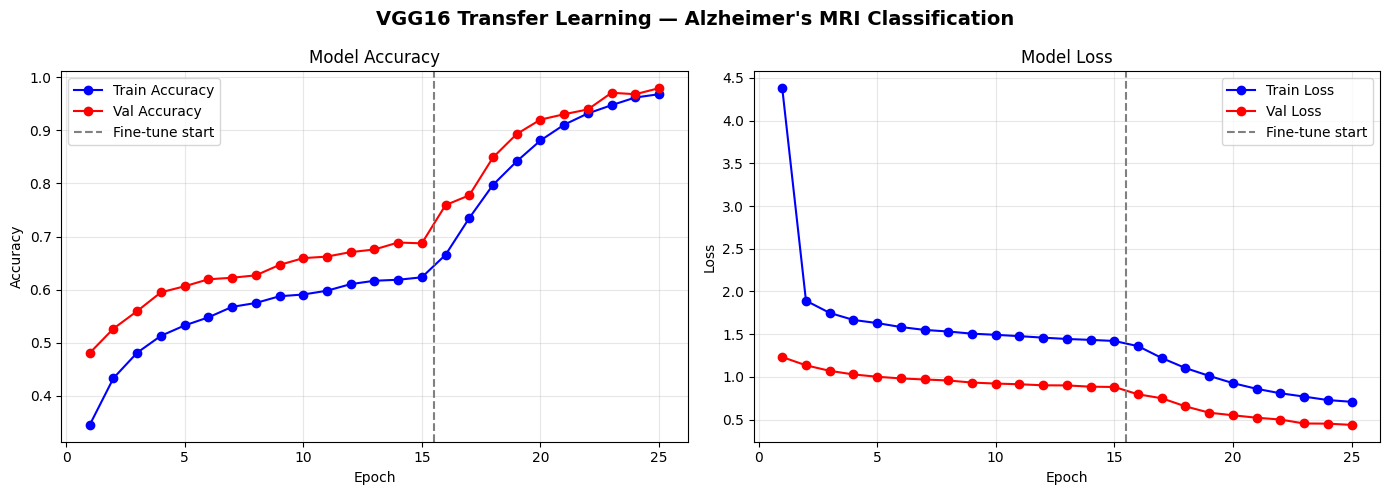

Training curves saved as 'training_curves.png'


In [16]:
if 'history_p1' in locals():
    # Combine phase 1 and phase 2 histories (if phase 2 ran)
    acc     = history_p1.history['accuracy']
    val_acc = history_p1.history['val_accuracy']
    loss    = history_p1.history['loss']
    val_loss= history_p1.history['val_loss']
    p1_len  = len(acc)

    if 'history_p2' in locals():
        acc      += history_p2.history['accuracy']
        val_acc  += history_p2.history['val_accuracy']
        loss     += history_p2.history['loss']
        val_loss += history_p2.history['val_loss']

    epochs_ran = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("VGG16 Transfer Learning — Alzheimer's MRI Classification", fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(epochs_ran, acc,     'b-o', label='Train Accuracy')
    axes[0].plot(epochs_ran, val_acc, 'r-o', label='Val Accuracy')
    if 'history_p2' in locals():
        axes[0].axvline(x=p1_len + 0.5, color='gray', linestyle='--', label='Fine-tune start')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(epochs_ran, loss,     'b-o', label='Train Loss')
    axes[1].plot(epochs_ran, val_loss, 'r-o', label='Val Loss')
    if 'history_p2' in locals():
        axes[1].axvline(x=p1_len + 0.5, color='gray', linestyle='--', label='Fine-tune start')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Training curves saved as 'training_curves.png'")
else:
    print("No training history found. Run the training cells first.")

## Prediction on New MRI Image


Processing: /content/1.jpg
Class probabilities:
  MildDemented             3.7%  █
  ModerateDemented         0.7%  
  NonDemented              0.7%  
  VeryMildDemented        94.9%  ████████████████████████████


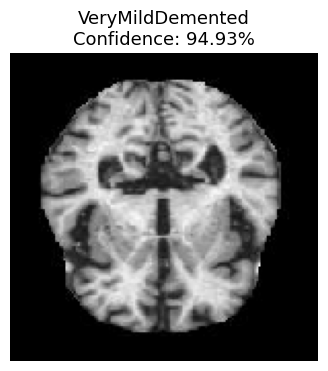


Predicted : VeryMildDemented
Confidence: 94.93%

Processing: /content/2.jpg
Class probabilities:
  MildDemented            93.8%  ████████████████████████████
  ModerateDemented         0.7%  
  NonDemented              1.9%  
  VeryMildDemented         3.6%  █


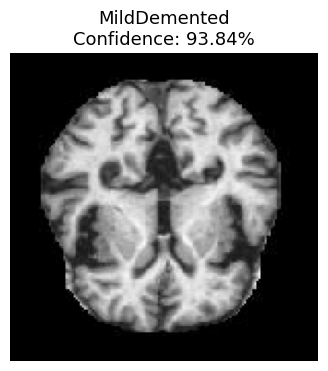


Predicted : MildDemented
Confidence: 93.84%

Processing: /content/3.jpg
Class probabilities:
  MildDemented             2.6%  
  ModerateDemented         1.0%  
  NonDemented             93.1%  ███████████████████████████
  VeryMildDemented         3.2%  


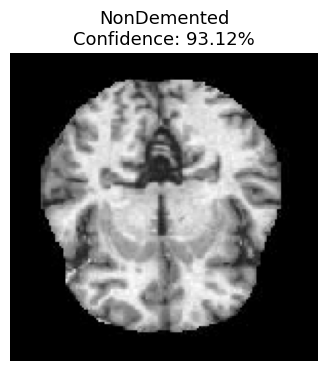


Predicted : NonDemented
Confidence: 93.12%

Processing: /content/4.jpg
Class probabilities:
  MildDemented            12.5%  ███
  ModerateDemented        70.6%  █████████████████████
  NonDemented             11.9%  ███
  VeryMildDemented         5.0%  █


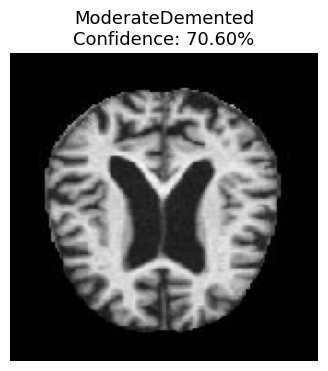


Predicted : ModerateDemented
Confidence: 70.60%

Processing: /content/5.jpg
Class probabilities:
  MildDemented            84.4%  █████████████████████████
  ModerateDemented         1.3%  
  NonDemented              5.2%  █
  VeryMildDemented         9.1%  ██


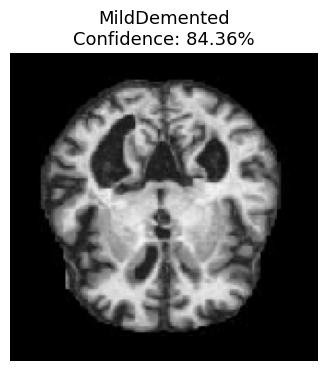


Predicted : MildDemented
Confidence: 84.36%

Processing: /content/6.jpg
Class probabilities:
  MildDemented            26.3%  ███████
  ModerateDemented         4.0%  █
  NonDemented             16.9%  █████
  VeryMildDemented        52.8%  ███████████████


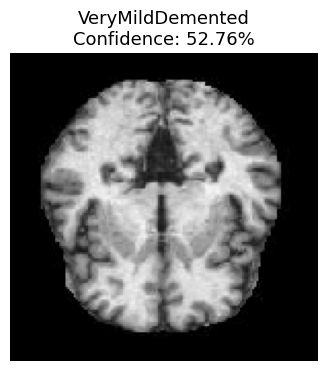


Predicted : VeryMildDemented
Confidence: 52.76%

Processing: /content/7.jpg
Class probabilities:
  MildDemented            13.9%  ████
  ModerateDemented        65.3%  ███████████████████
  NonDemented              2.5%  
  VeryMildDemented        18.3%  █████


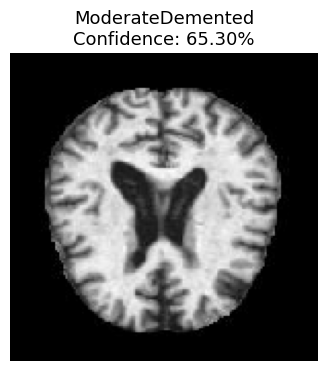


Predicted : ModerateDemented
Confidence: 65.30%

Processing: /content/8.jpg
Class probabilities:
  MildDemented             1.7%  
  ModerateDemented         2.2%  
  NonDemented              8.1%  ██
  VeryMildDemented        88.0%  ██████████████████████████


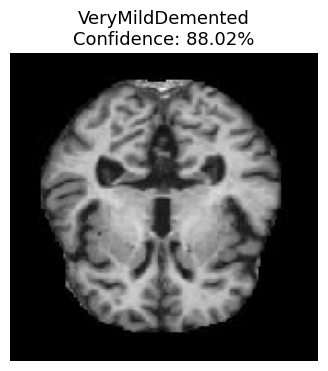


Predicted : VeryMildDemented
Confidence: 88.02%

Processing: /content/9.jpg
Class probabilities:
  MildDemented             8.2%  ██
  ModerateDemented        70.1%  █████████████████████
  NonDemented              9.6%  ██
  VeryMildDemented        12.1%  ███


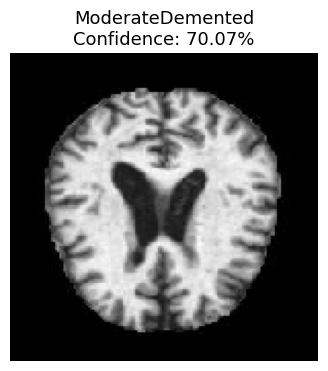


Predicted : ModerateDemented
Confidence: 70.07%

Processing: /content/10.jpg
Class probabilities:
  MildDemented            40.2%  ████████████
  ModerateDemented         4.3%  █
  NonDemented             48.2%  ██████████████
  VeryMildDemented         7.3%  ██


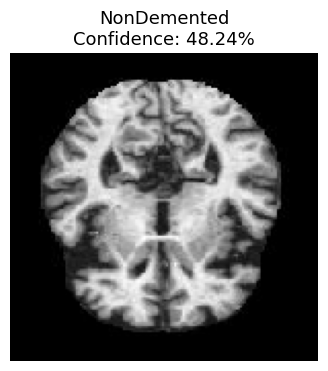


Predicted : NonDemented
Confidence: 48.24%

Processing: /content/11.jpg
Class probabilities:
  MildDemented             1.5%  
  ModerateDemented         0.9%  
  NonDemented              4.1%  █
  VeryMildDemented        93.6%  ████████████████████████████


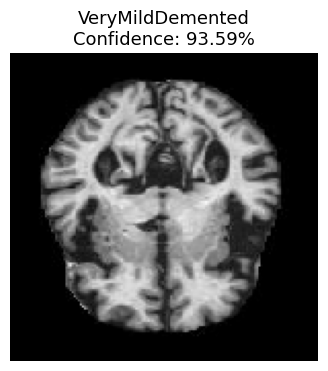


Predicted : VeryMildDemented
Confidence: 93.59%

Processing: /content/12.jpg
Class probabilities:
  MildDemented             0.2%  
  ModerateDemented         1.0%  
  NonDemented             98.4%  █████████████████████████████
  VeryMildDemented         0.4%  


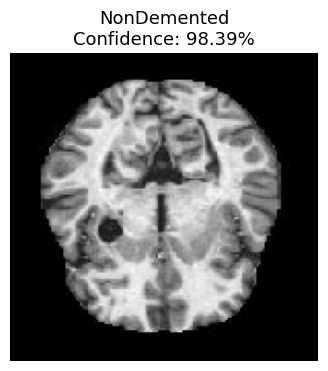


Predicted : NonDemented
Confidence: 98.39%

Processing: /content/13.jpg
Class probabilities:
  MildDemented            85.3%  █████████████████████████
  ModerateDemented         3.1%  
  NonDemented              6.3%  █
  VeryMildDemented         5.3%  █


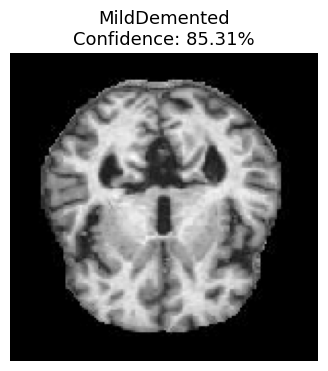


Predicted : MildDemented
Confidence: 85.31%

Processing: /content/14.jpg
Class probabilities:
  MildDemented             1.6%  
  ModerateDemented         2.8%  
  NonDemented              1.9%  
  VeryMildDemented        93.7%  ████████████████████████████


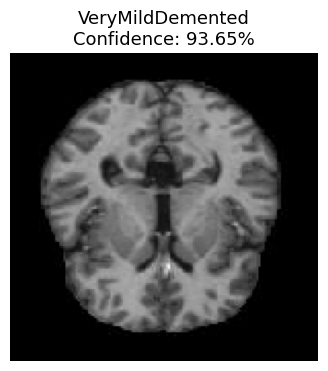


Predicted : VeryMildDemented
Confidence: 93.65%

Processing: /content/15.jpg
Class probabilities:
  MildDemented            13.4%  ████
  ModerateDemented         3.8%  █
  NonDemented             58.3%  █████████████████
  VeryMildDemented        24.5%  ███████


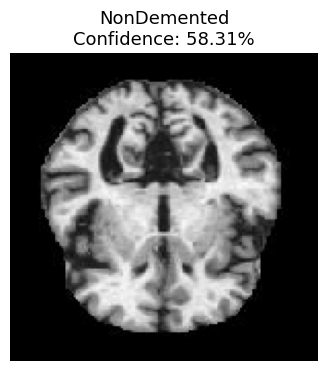


Predicted : NonDemented
Confidence: 58.31%

Processing: /content/16.jpg
Class probabilities:
  MildDemented             0.0%  
  ModerateDemented         0.1%  
  NonDemented             99.1%  █████████████████████████████
  VeryMildDemented         0.8%  


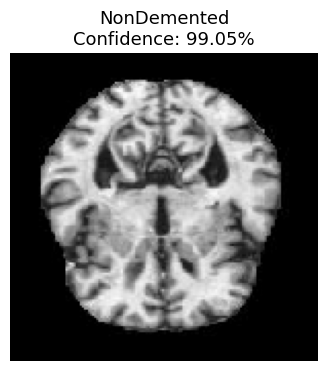


Predicted : NonDemented
Confidence: 99.05%

Processing: /content/17.jpg
Class probabilities:
  MildDemented            16.6%  ████
  ModerateDemented        75.0%  ██████████████████████
  NonDemented              6.2%  █
  VeryMildDemented         2.2%  


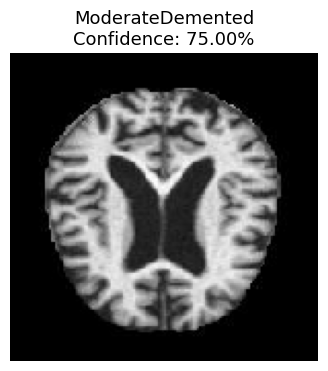


Predicted : ModerateDemented
Confidence: 75.00%

Processing: /content/18.jpg
Class probabilities:
  MildDemented             1.1%  
  ModerateDemented         1.1%  
  NonDemented             96.2%  ████████████████████████████
  VeryMildDemented         1.5%  


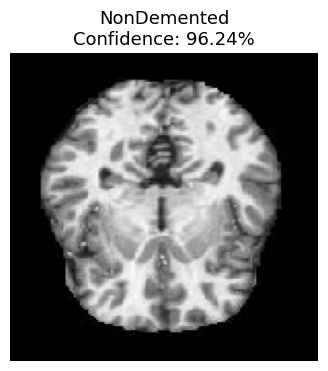


Predicted : NonDemented
Confidence: 96.24%

Processing: /content/19.jpg
Class probabilities:
  MildDemented             2.2%  
  ModerateDemented         1.3%  
  NonDemented             91.5%  ███████████████████████████
  VeryMildDemented         5.0%  █


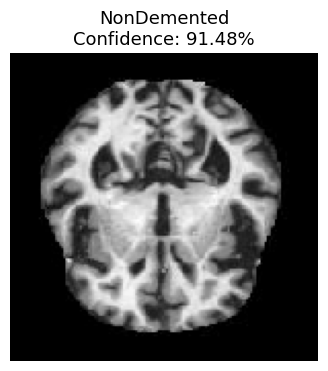


Predicted : NonDemented
Confidence: 91.48%

Processing: /content/20.jpg
Class probabilities:
  MildDemented            91.7%  ███████████████████████████
  ModerateDemented         3.0%  
  NonDemented              2.6%  
  VeryMildDemented         2.7%  


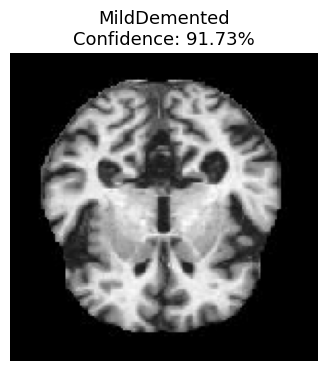


Predicted : MildDemented
Confidence: 91.73%


In [21]:
def predict_image(model, image_path, class_names=None):
    """Predict Alzheimer's classification for a given MRI image path."""
    if not os.path.exists(image_path):
        print(f"Error: Image not found at '{image_path}'")
        return

    # Default class labels for Alzheimer's
    if class_names is None:
        class_names = ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']

    img = load_img(image_path, target_size=(IMG_WIDTH, IMG_HEIGHT))
    img_array = img_to_array(img)
    # Normalize to [0,1] — matches the training pipeline
    img_array = np.expand_dims(img_array, axis=0) # Preprocessing is handled inside the model

    predictions = model.predict(img_array, verbose=0)
    predicted_idx = np.argmax(predictions[0])
    confidence    = predictions[0][predicted_idx]

    # Show all class probabilities
    print("Class probabilities:")
    for name, prob in zip(class_names, predictions[0]):
        bar = '█' * int(prob * 30)
        print(f"  {name:<22} {prob*100:5.1f}%  {bar}")

    # Show image with prediction
    plt.figure(figsize=(4, 4))
    plt.imshow(load_img(image_path, target_size=(IMG_WIDTH, IMG_HEIGHT)))
    plt.title(f"{class_names[predicted_idx]}\nConfidence: {confidence*100:.2f}%", fontsize=13)
    plt.axis('off')
    plt.show()

    print(f"\nPredicted : {class_names[predicted_idx]}")
    print(f"Confidence: {confidence * 100:.2f}%")

# --- Usage ---
folder_path = "/content"  # change if your images are in a different folder

for i in range(1, 21):
    img_path = os.path.join(folder_path, f"{i}.jpg")
    print(f"\nProcessing: {img_path}")
    predict_image(model, img_path, class_names)

In [18]:
model.save("/content/alzheimer_model.h5")

In [19]:
from google.colab import files
files.download("/content/alzheimer_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
loss, accuracy = model.evaluate(test_dataset)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

160/160 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.9742 - loss: 0.4397
Test Accuracy: 97.42%
